In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [88]:
import os
print(os.listdir()) # คำสั่งนี้จะลิสต์ชื่อไฟล์ทั้งหมดในโฟลเดอร์ปัจจุบันออกมา

['.ipynb_checkpoints', '20260212FM-1_BearingDefect.xlsx', '20260212FM-1_BearingDefect_EDA_Cleaned.ipynb', 'BearingDefect_Cleaned_Y9_Y13.csv', 'Bearing_Data_Final_Clean.csv', 'Bearing_Data_No_Zeros.csv', 'TWF']


In [90]:
# 1. โหลดข้อมูล
file_path = '20260212FM-1_BearingDefect.xlsx'
df = pd.read_excel(file_path)

In [92]:
df.head()

,date,time,machine,Bearing No.,Shaft Speed of Motor (RPM),point,Severity of Unbalance Problem_Motor_(Y1),Severity of Misalignment Problem (Y2),Severity of Looseness Problem (Type A) (Y3),Severity of Looseness Problem (Type B) (Y3),...,Severity of Structural Resonance (Y6),Severity of Lubrication Problem (Y7),Severity of Vane pass (Y8),BPFO (Y9),BPFI (Y10),FTF (Y11),BSF (Y12),Severity of bearing defect (Y13),Unnamed: 20,Unnamed: 21
0,2025-06-27,NaN,P-210S,Sleeve bearing,1470,M1A,1,1,1,1,...,1,1,0,1,1,1,1,1.0,NaN,NaN
1,2025-06-27,NaN,P-210S,Sleeve bearing,1470,M1V,1,1,1,1,...,1,1,0,1,1,1,1,1.0,NaN,NaN
2,2025-06-27,NaN,P-210S,Sleeve bearing,1470,M1H,1,1,1,1,...,1,1,0,1,1,1,1,1.0,NaN,NaN
3,2025-06-27,NaN,P-210S,Sleeve bearing,1470,M2A,1,1,1,1,...,1,1,0,1,1,1,1,1.0,NaN,NaN
4,2025-06-27,NaN,P-210S,Sleeve bearing,1470,M2V,1,1,1,1,...,1,1,0,1,1,1,1,1.0,NaN,NaN


In [94]:
# 2. การเตรียมข้อมูล (Data Cleaning)
# ลบคอลัมน์ที่ว่างเปล่าเกินไป
df_clean = df.drop(columns=['time', 'Unnamed: 20', 'Unnamed: 21'])


In [96]:
df_clean.head()

,date,machine,Bearing No.,Shaft Speed of Motor (RPM),point,Severity of Unbalance Problem_Motor_(Y1),Severity of Misalignment Problem (Y2),Severity of Looseness Problem (Type A) (Y3),Severity of Looseness Problem (Type B) (Y3),Severity of Looseness Problem (Type C) (Y4),Severity of Electrical (2FL) (Y5),Severity of Structural Resonance (Y6),Severity of Lubrication Problem (Y7),Severity of Vane pass (Y8),BPFO (Y9),BPFI (Y10),FTF (Y11),BSF (Y12),Severity of bearing defect (Y13)
0,2025-06-27,P-210S,Sleeve bearing,1470,M1A,1,1,1,1,1,1,1,1,0,1,1,1,1,1.0
1,2025-06-27,P-210S,Sleeve bearing,1470,M1V,1,1,1,1,1,1,1,1,0,1,1,1,1,1.0
2,2025-06-27,P-210S,Sleeve bearing,1470,M1H,1,1,1,1,1,1,1,1,0,1,1,1,1,1.0
3,2025-06-27,P-210S,Sleeve bearing,1470,M2A,1,1,1,1,1,1,1,1,0,1,1,1,1,1.0
4,2025-06-27,P-210S,Sleeve bearing,1470,M2V,1,1,1,1,1,1,1,1,0,1,1,1,1,1.0


In [98]:
df_clean.isnull().sum() # ใช้สรุปว่า แต่ละคอลัมน์มีค่าว่างกี่จุด

date                                             4
machine                                          0
Bearing No.                                    214
Shaft Speed of Motor (RPM)                     172
point                                            8
Severity of Unbalance Problem_Motor_(Y1)        44
Severity of Misalignment Problem (Y2)           45
Severity of Looseness Problem (Type A) (Y3)     45
Severity of Looseness Problem (Type B) (Y3)     45
Severity of Looseness Problem (Type C) (Y4)     45
Severity of Electrical (2FL) (Y5)              266
Severity of Structural Resonance (Y6)          400
Severity of Lubrication Problem (Y7)           400
Severity of Vane pass (Y8)                     279
BPFO (Y9)                                       45
BPFI (Y10)                                      45
FTF (Y11)                                       45
BSF (Y12)                                       45
Severity of bearing defect (Y13)                63
dtype: int64

In [100]:
# แปลงคอลัมน์ Severity (Y1-Y13) ให้เป็นตัวเลข (Numeric)
severity_cols = [col for col in df_clean.columns if '(Y' in col or 'BPF' in col or 'FTF' in col or 'BSF' in col]
for col in severity_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [102]:
# ลบแถวที่มีค่าว่างในคอลัมน์หลัก
df_clean = df_clean.dropna(subset=['Severity of bearing defect (Y13)'])

In [104]:
df_clean.isnull().sum() # ใช้สรุปว่า แต่ละคอลัมน์มีค่าว่างกี่จุด

date                                             0
machine                                          0
Bearing No.                                    202
Shaft Speed of Motor (RPM)                     146
point                                            0
Severity of Unbalance Problem_Motor_(Y1)         0
Severity of Misalignment Problem (Y2)            0
Severity of Looseness Problem (Type A) (Y3)      0
Severity of Looseness Problem (Type B) (Y3)      0
Severity of Looseness Problem (Type C) (Y4)      0
Severity of Electrical (2FL) (Y5)              221
Severity of Structural Resonance (Y6)          355
Severity of Lubrication Problem (Y7)           355
Severity of Vane pass (Y8)                     234
BPFO (Y9)                                        0
BPFI (Y10)                                       0
FTF (Y11)                                        0
BSF (Y12)                                        0
Severity of bearing defect (Y13)                 0
dtype: int64

In [106]:
#กำหนดรายชื่อ Column ที่ต้องการลบ (Y1 - Y8)
cols_to_drop = [
    'Severity of Unbalance Problem_Motor_(Y1)',
    'Severity of Misalignment Problem (Y2)',
    'Severity of Looseness Problem (Type A) (Y3)',
    'Severity of Looseness Problem (Type B) (Y3)',
    'Severity of Looseness Problem (Type C) (Y4)',
    'Severity of Electrical (2FL) (Y5)',
    'Severity of Structural Resonance (Y6)',
    'Severity of Lubrication Problem (Y7)',
    'Severity of Vane pass (Y8)'
]

# 3. ใช้คำสั่ง .drop() 
# axis=1 หมายถึงการลบแนวตั้ง (Column)
# errors='ignore' ใส่ไว้เผื่อกรณีรันซ้ำแล้วหาคอลัมน์ไม่เจอ จะได้ไม่ฟ้อง Error ครับ
df_dropped = df.drop(columns=cols_to_drop, errors='ignore')

# ลบคอลัมน์ที่ว่างเปล่าเพิ่มเติมเพื่อให้ข้อมูลดูง่าย
df_cleaned = df_dropped.drop(columns=['time', 'Unnamed: 20', 'Unnamed: 21'], errors='ignore')

# 4. แสดงผลลัพธ์
print("คอลัมน์ที่เหลืออยู่ตอนนี้:")
print(df_cleaned.columns.tolist())



คอลัมน์ที่เหลืออยู่ตอนนี้:
['date', 'machine', 'Bearing No.', 'Shaft Speed of Motor (RPM)', 'point', 'BPFO (Y9)', 'BPFI (Y10)', 'FTF (Y11)', 'BSF (Y12)', 'Severity of bearing defect (Y13)']


In [108]:
df_cleaned.isnull().sum() # ใช้สรุปว่า แต่ละคอลัมน์มีค่าว่างกี่จุด

date                                  4
machine                               0
Bearing No.                         214
Shaft Speed of Motor (RPM)          172
point                                 8
BPFO (Y9)                            45
BPFI (Y10)                           45
FTF (Y11)                            45
BSF (Y12)                            45
Severity of bearing defect (Y13)     63
dtype: int64

In [110]:
df_cleaned1 = df_cleaned.drop(columns=['Bearing No.'], errors='ignore')

In [112]:
df_cleaned1.isnull().sum() # ใช้สรุปว่า แต่ละคอลัมน์มีค่าว่างกี่จุด

date                                  4
machine                               0
Shaft Speed of Motor (RPM)          172
point                                 8
BPFO (Y9)                            45
BPFI (Y10)                           45
FTF (Y11)                            45
BSF (Y12)                            45
Severity of bearing defect (Y13)     63
dtype: int64

In [114]:
df_cleaned1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              2495 non-null   datetime64[ns]
 1   machine                           2499 non-null   object        
 2   Shaft Speed of Motor (RPM)        2327 non-null   object        
 3   point                             2491 non-null   object        
 4   BPFO (Y9)                         2454 non-null   object        
 5   BPFI (Y10)                        2454 non-null   object        
 6   FTF (Y11)                         2454 non-null   object        
 7   BSF (Y12)                         2454 non-null   object        
 8   Severity of bearing defect (Y13)  2436 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 175.8+ KB


In [116]:
# ลบทุกแถวที่ยังมีค่าว่าง (Null) หลงเหลืออยู่
# คำสั่งนี้จะทำให้มั่นใจว่าทุกช่องในตารางจะมีข้อมูลครบถ้วน
df_final = df_cleaned1.dropna()

In [118]:
# 5. ตรวจสอบผลลัพธ์
print(f"จำนวนข้อมูลที่พร้อมใช้งาน: {df_final.shape[0]} แถว")
print(f"จำนวนค่าว่างคงเหลือ: {df_final.isnull().sum().sum()}")

จำนวนข้อมูลที่พร้อมใช้งาน: 2290 แถว
จำนวนค่าว่างคงเหลือ: 0


In [120]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2290 entries, 0 to 2426
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              2290 non-null   datetime64[ns]
 1   machine                           2290 non-null   object        
 2   Shaft Speed of Motor (RPM)        2290 non-null   object        
 3   point                             2290 non-null   object        
 4   BPFO (Y9)                         2290 non-null   object        
 5   BPFI (Y10)                        2290 non-null   object        
 6   FTF (Y11)                         2290 non-null   object        
 7   BSF (Y12)                         2290 non-null   object        
 8   Severity of bearing defect (Y13)  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 178.9+ KB


In [122]:
# 6. บันทึกไฟล์ที่สะอาดแล้ว
df_final.to_csv('Bearing_Data_Final_Clean.csv', index=False)

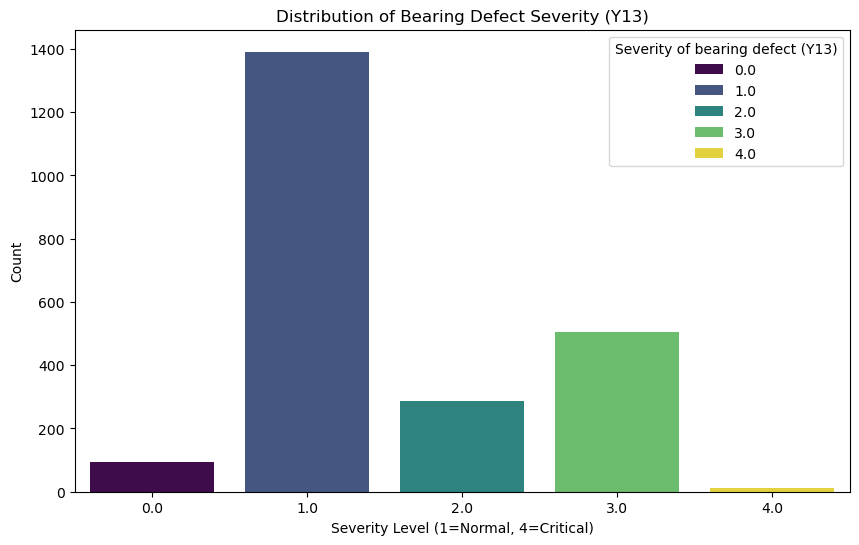

In [126]:
# 4. การสร้าง Visualization เพื่อดู Insight
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='Severity of bearing defect (Y13)', hue='Severity of bearing defect (Y13)', palette='viridis')
plt.title('Distribution of Bearing Defect Severity (Y13)')
plt.xlabel('Severity Level (1=Normal, 4=Critical)')
plt.ylabel('Count')
plt.show()

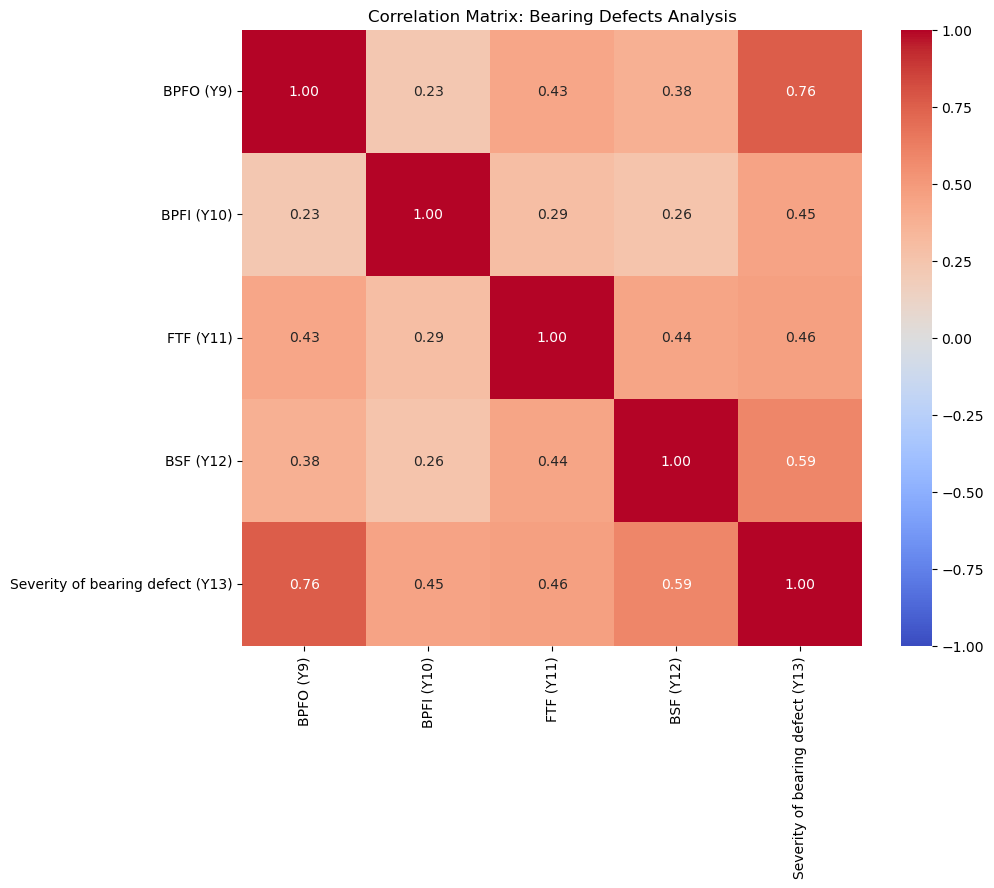

Correlation Table:
Severity of bearing defect (Y13)    1.000000
BPFO (Y9)                           0.759910
BSF (Y12)                           0.588752
FTF (Y11)                           0.464465
BPFI (Y10)                          0.450520
Name: Severity of bearing defect (Y13), dtype: float64


In [128]:
# 1. โหลดข้อมูลที่ Clean แล้ว
df = pd.read_csv('Bearing_Data_Final_Clean.csv')

# 2. เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขความรุนแรง (Y9 - Y13) มาวิเคราะห์
# เราเลือกเฉพาะกลุ่มนี้เพราะต้องการดูว่าอาการเสียจุดไหนสัมพันธ์กับความรุนแรงรวม
cols_to_analyze = [
    'BPFO (Y9)', 
    'BPFI (Y10)', 
    'FTF (Y11)', 
    'BSF (Y12)', 
    'Severity of bearing defect (Y13)'
]

# 3. คำนวณค่า Correlation (ความสัมพันธ์ระหว่างตัวแปร)
# ค่าที่ได้จะอยู่ระหว่าง -1 ถึง 1
corr_matrix = df[cols_to_analyze].corr()

# 4. สร้างการแสดงผลด้วย Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,      # แสดงตัวเลขกำกับในช่อง
    cmap='coolwarm', # ใช้โทนสี เย็น(น้ำเงิน)-ร้อน(แดง)
    fmt=".2f",       # แสดงทศนิยม 2 ตำแหน่ง
    vmin=-1, vmax=1, # กำหนดช่วงค่าสีให้ชัดเจน
    center=0
)

plt.title('Correlation Matrix: Bearing Defects Analysis')
plt.show()

# 5. แสดงผลค่า Correlation ในรูปแบบตาราง (Optional)
print("Correlation Table:")
print(corr_matrix['Severity of bearing defect (Y13)'].sort_values(ascending=False))

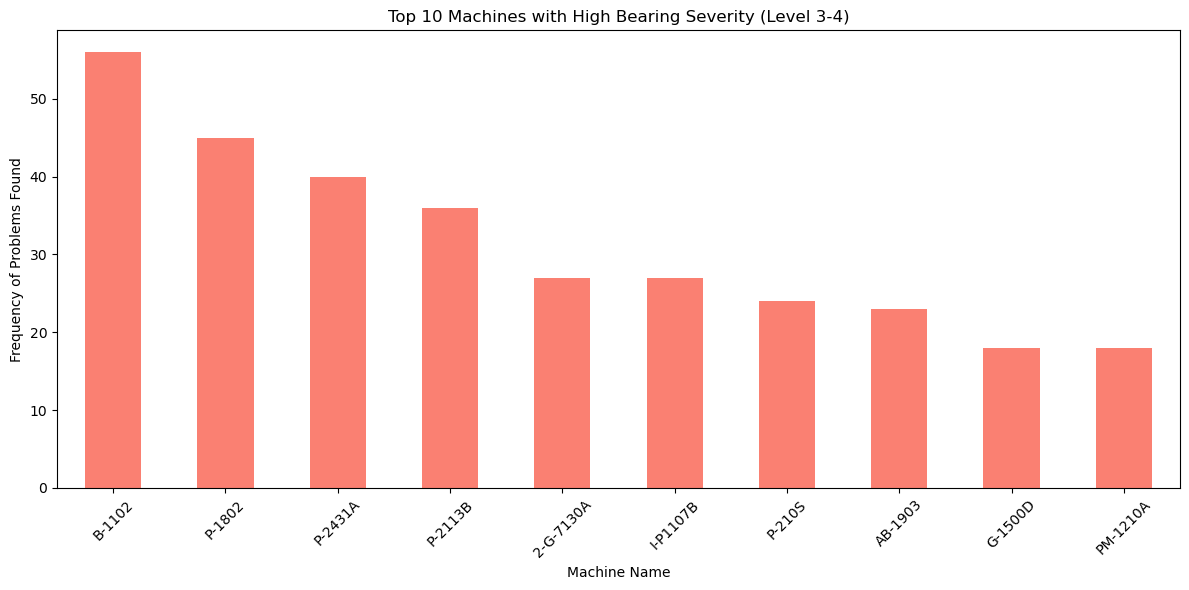

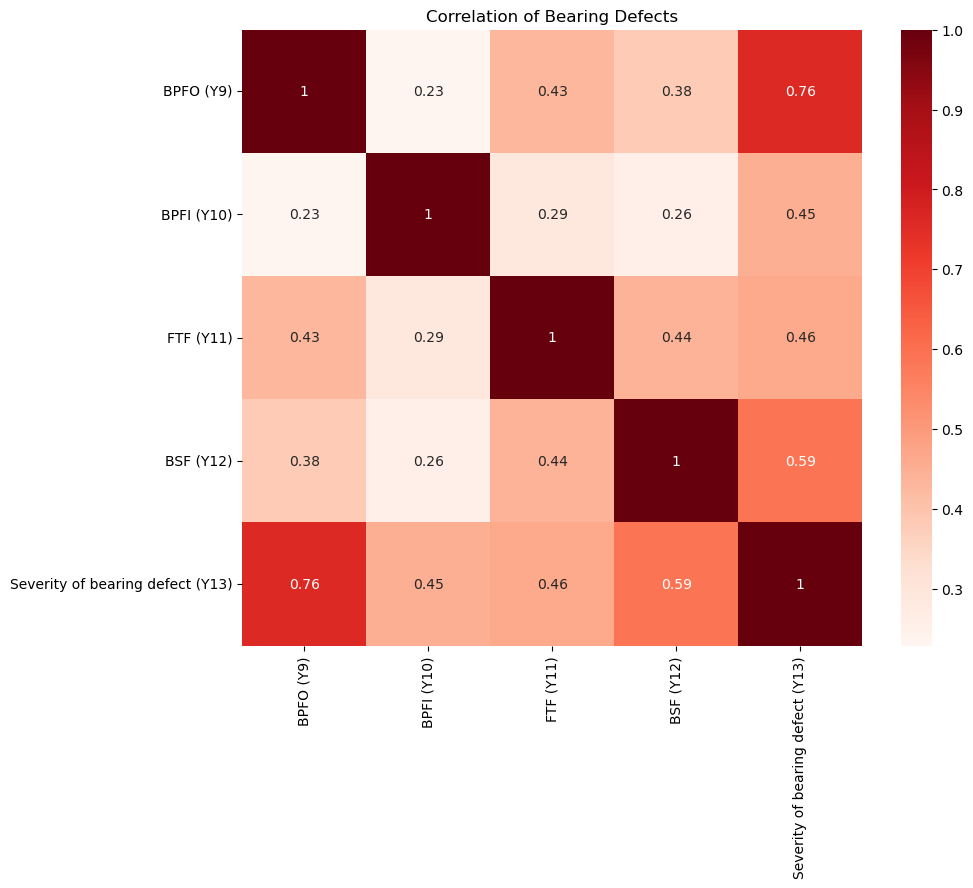

In [130]:
# วิเคราะห์หาเครื่องจักรที่มีปัญหาหนัก (Severity 3 และ 4)
high_risk = df[df['Severity of bearing defect (Y13)'] >= 3]
top_machines = high_risk['machine'].value_counts().head(10)

# วาดกราฟ 10 อันดับเครื่องจักรที่มีปัญหา
plt.figure(figsize=(12, 6))
top_machines.plot(kind='bar', color='salmon')
plt.title('Top 10 Machines with High Bearing Severity (Level 3-4)')
plt.ylabel('Frequency of Problems Found')
plt.xlabel('Machine Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ดูความสัมพันธ์ระหว่างความรุนแรงของแต่ละจุด
plt.figure(figsize=(10, 8))
severity_cols = ['BPFO (Y9)', 'BPFI (Y10)', 'FTF (Y11)', 'BSF (Y12)', 'Severity of bearing defect (Y13)']
sns.heatmap(df[severity_cols].corr(), annot=True, cmap='Reds')
plt.title('Correlation of Bearing Defects')
plt.show()

In [131]:
# ลบแถวที่คอลัมน์ Y13 มีค่าเท่ากับ 0
# เราใช้เครื่องหมาย != เพื่อเลือกเอาเฉพาะแถวที่ไม่ใช่ 0
df_filtered = df[df['Severity of bearing defect (Y13)'] != 0].copy()

# 3. ตรวจสอบจำนวนข้อมูลที่เหลือ
print(f"จำนวนแถวที่ถูกลบออก (ค่าเป็น 0): {len(df) - len(df_filtered)}")
print(f"จำนวนแถวที่เหลือใช้งาน: {len(df_filtered)}")

# 4. บันทึกไฟล์ใหม่ (เพื่อใช้ทำ Model ต่อไป)
df_filtered.to_csv('Bearing_Data_No_Zeros.csv', index=False)

จำนวนแถวที่ถูกลบออก (ค่าเป็น 0): 94
จำนวนแถวที่เหลือใช้งาน: 2196


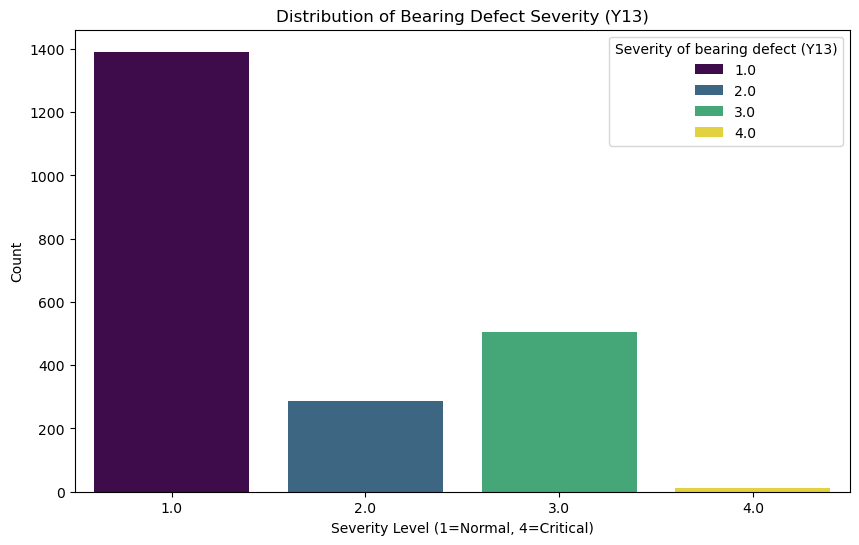

In [134]:
# การสร้าง Visualization เพื่อดู Insight
plt.figure(figsize=(10, 6))
sns.countplot(data=df_filtered, x='Severity of bearing defect (Y13)', hue='Severity of bearing defect (Y13)', palette='viridis')
plt.title('Distribution of Bearing Defect Severity (Y13)')
plt.xlabel('Severity Level (1=Normal, 4=Critical)')
plt.ylabel('Count')
plt.show()